In [1]:
from pathlib import Path
import sys
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
sys.path.append(str(Path.cwd().parents[1] / "code"))
from utils import *

## Experiment setup

In [ ]:
# Construct the physical graph.
markov_graph = open_graph("markov_chain")
G = nx.Graph()
for node in markov_graph:
    neighbors = markov_graph[node][1]
    for node2 in neighbors:
        if node[0] != node2:
            G.add_edge(node[0], node2)


# Experiment parameters.
sparsity = 0
max_order = 4
n_walkers = 3
n_iter = 1000
seq_len = 100000


# Construct Markov chains of different orders and compute
# theoretical contact probabilities.
list_chains = []
list_stat = []
for i in range(max_order):
    if i > 0:
        markov_graph = build_kth_order_markov_graph(
            graph=G,
            k=i,
            sparsity=sparsity,
        )
    print(f"Computing statistics for order {i + 1}...")

    obj = compute_ss_contact_probabilities(
        markov_graph,
        n_walkers,
        precision=20,
        is_approximate=True,
    )

    list_chains.append(markov_graph)
    list_stat.append(obj)

## Simulation and statistics

In [ ]:
# Simulate contacts for different Markov orders.

tot_occurrence3_by_order = np.zeros((max_order, seq_len), dtype=np.int64)

tot_joint_occurrence3_by_order = np.zeros((max_order, seq_len - 1), dtype=np.int64)

for i in tqdm(range(max_order), desc="Markov order"):
    markov_graph = list_chains[i]
    tot_occurrence3 = np.zeros(seq_len, dtype=np.int64)
    tot_joint_occurrence3 = np.zeros(seq_len - 1, dtype=np.int64)

    for _ in tqdm(range(n_iter), desc=f"order {i + 1}", leave=False):
        positions = run_walkers(
            markov_graph,
            seq_len,
            n_walkers,
            disable_tqdm=True,
        )

        occurrence3 = np.all(positions == positions[:, [0]], axis=1,
        ).astype(int)

        joint_occurrence3 = (
            occurrence3[:-1] * occurrence3[1:]
        )

        tot_occurrence3 += occurrence3
        tot_joint_occurrence3 += joint_occurrence3

    tot_occurrence3_by_order[i] = tot_occurrence3
    tot_joint_occurrence3_by_order[i] = tot_joint_occurrence3


cum = np.cumsum(tot_occurrence3_by_order, axis=1)
den = np.arange(1, seq_len + 1) * n_iter

p_data = cum / den

v = np.array(
    [list_stat[i]["prob"][3] for i in range(max_order)],
    dtype=float,
)[:, None]

rel_error = np.abs(p_data - v) / v


# Consecutive-time contact probabilities.

cum2 = np.cumsum(tot_joint_occurrence3_by_order, axis=1)
den2 = np.arange(1, seq_len) * n_iter

p_data2 = cum2 / den2

v2 = np.array(
    [list_stat[i]["joint_prob"][3] for i in range(max_order)],
    dtype=float,
)[:, None]

rel_error2 = np.abs(p_data2 - v2) / v2

## Alternative: load precomputed results

In [2]:
[list_chains,tot_occurrence3_by_order,tot_joint_occurrence3_by_order,num_occ_by_order,seq_len,n_iter,rel_error,rel_error2] = open_graph("contact_statistics_order")

## Visualization

In [3]:
sns.set_theme(style="ticks", context="paper", palette="colorblind")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 20,
    "axes.titlesize": 30,
    "axes.labelsize": 20,
    "legend.fontsize": 22,
    "legend.title_fontsize": 25,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "lines.linewidth": 4,
    "axes.linewidth": 0.8,
})

In [4]:
# Plot convergence for different Markov orders.
def plot_order_convergence(rel_error, global_max, filename, tick_size = 5000):
    colors = np.array(sns.color_palette("muted", 4))

    x = np.arange(
        1,
        min(100000, rel_error.shape[1]) + 1,
    )

    labels = [
        "p = 1",
        "p = 2",
        "p = 3",
        "p = 4",
    ]

    fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

    for i in range(min(4, rel_error.shape[0])):
        ax.plot(
            x,
            rel_error[i, :len(x)],
            color=colors[i],
            label=labels[i],
        )

    ax.set_xlabel(
        "Length of contact graph sequence ($K$)",
        fontsize=30,
    )
    ax.set_ylabel(
        "Relative error",
        fontsize=30,
    )

    global_min = 0

    ax.grid(
        True,
        linestyle="--",
        alpha=0.25,
        linewidth=0.7,
    )

    leg = ax.legend(
        title=r"Markov order, p",
        frameon=True,
        bbox_to_anchor=(1.005, 1.01),
    )

    for line in leg.get_lines():
        line.set_linewidth(8)

    ax.set_xlim(global_min, global_max)
    ax.set_ylim(0, 1)

    plt.xticks(
        np.arange(0, global_max + 1, tick_size)
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both")

    plt.tight_layout()

    plt.savefig(
        filename,
        bbox_inches="tight",
        dpi=300,
    )

    plt.show()

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

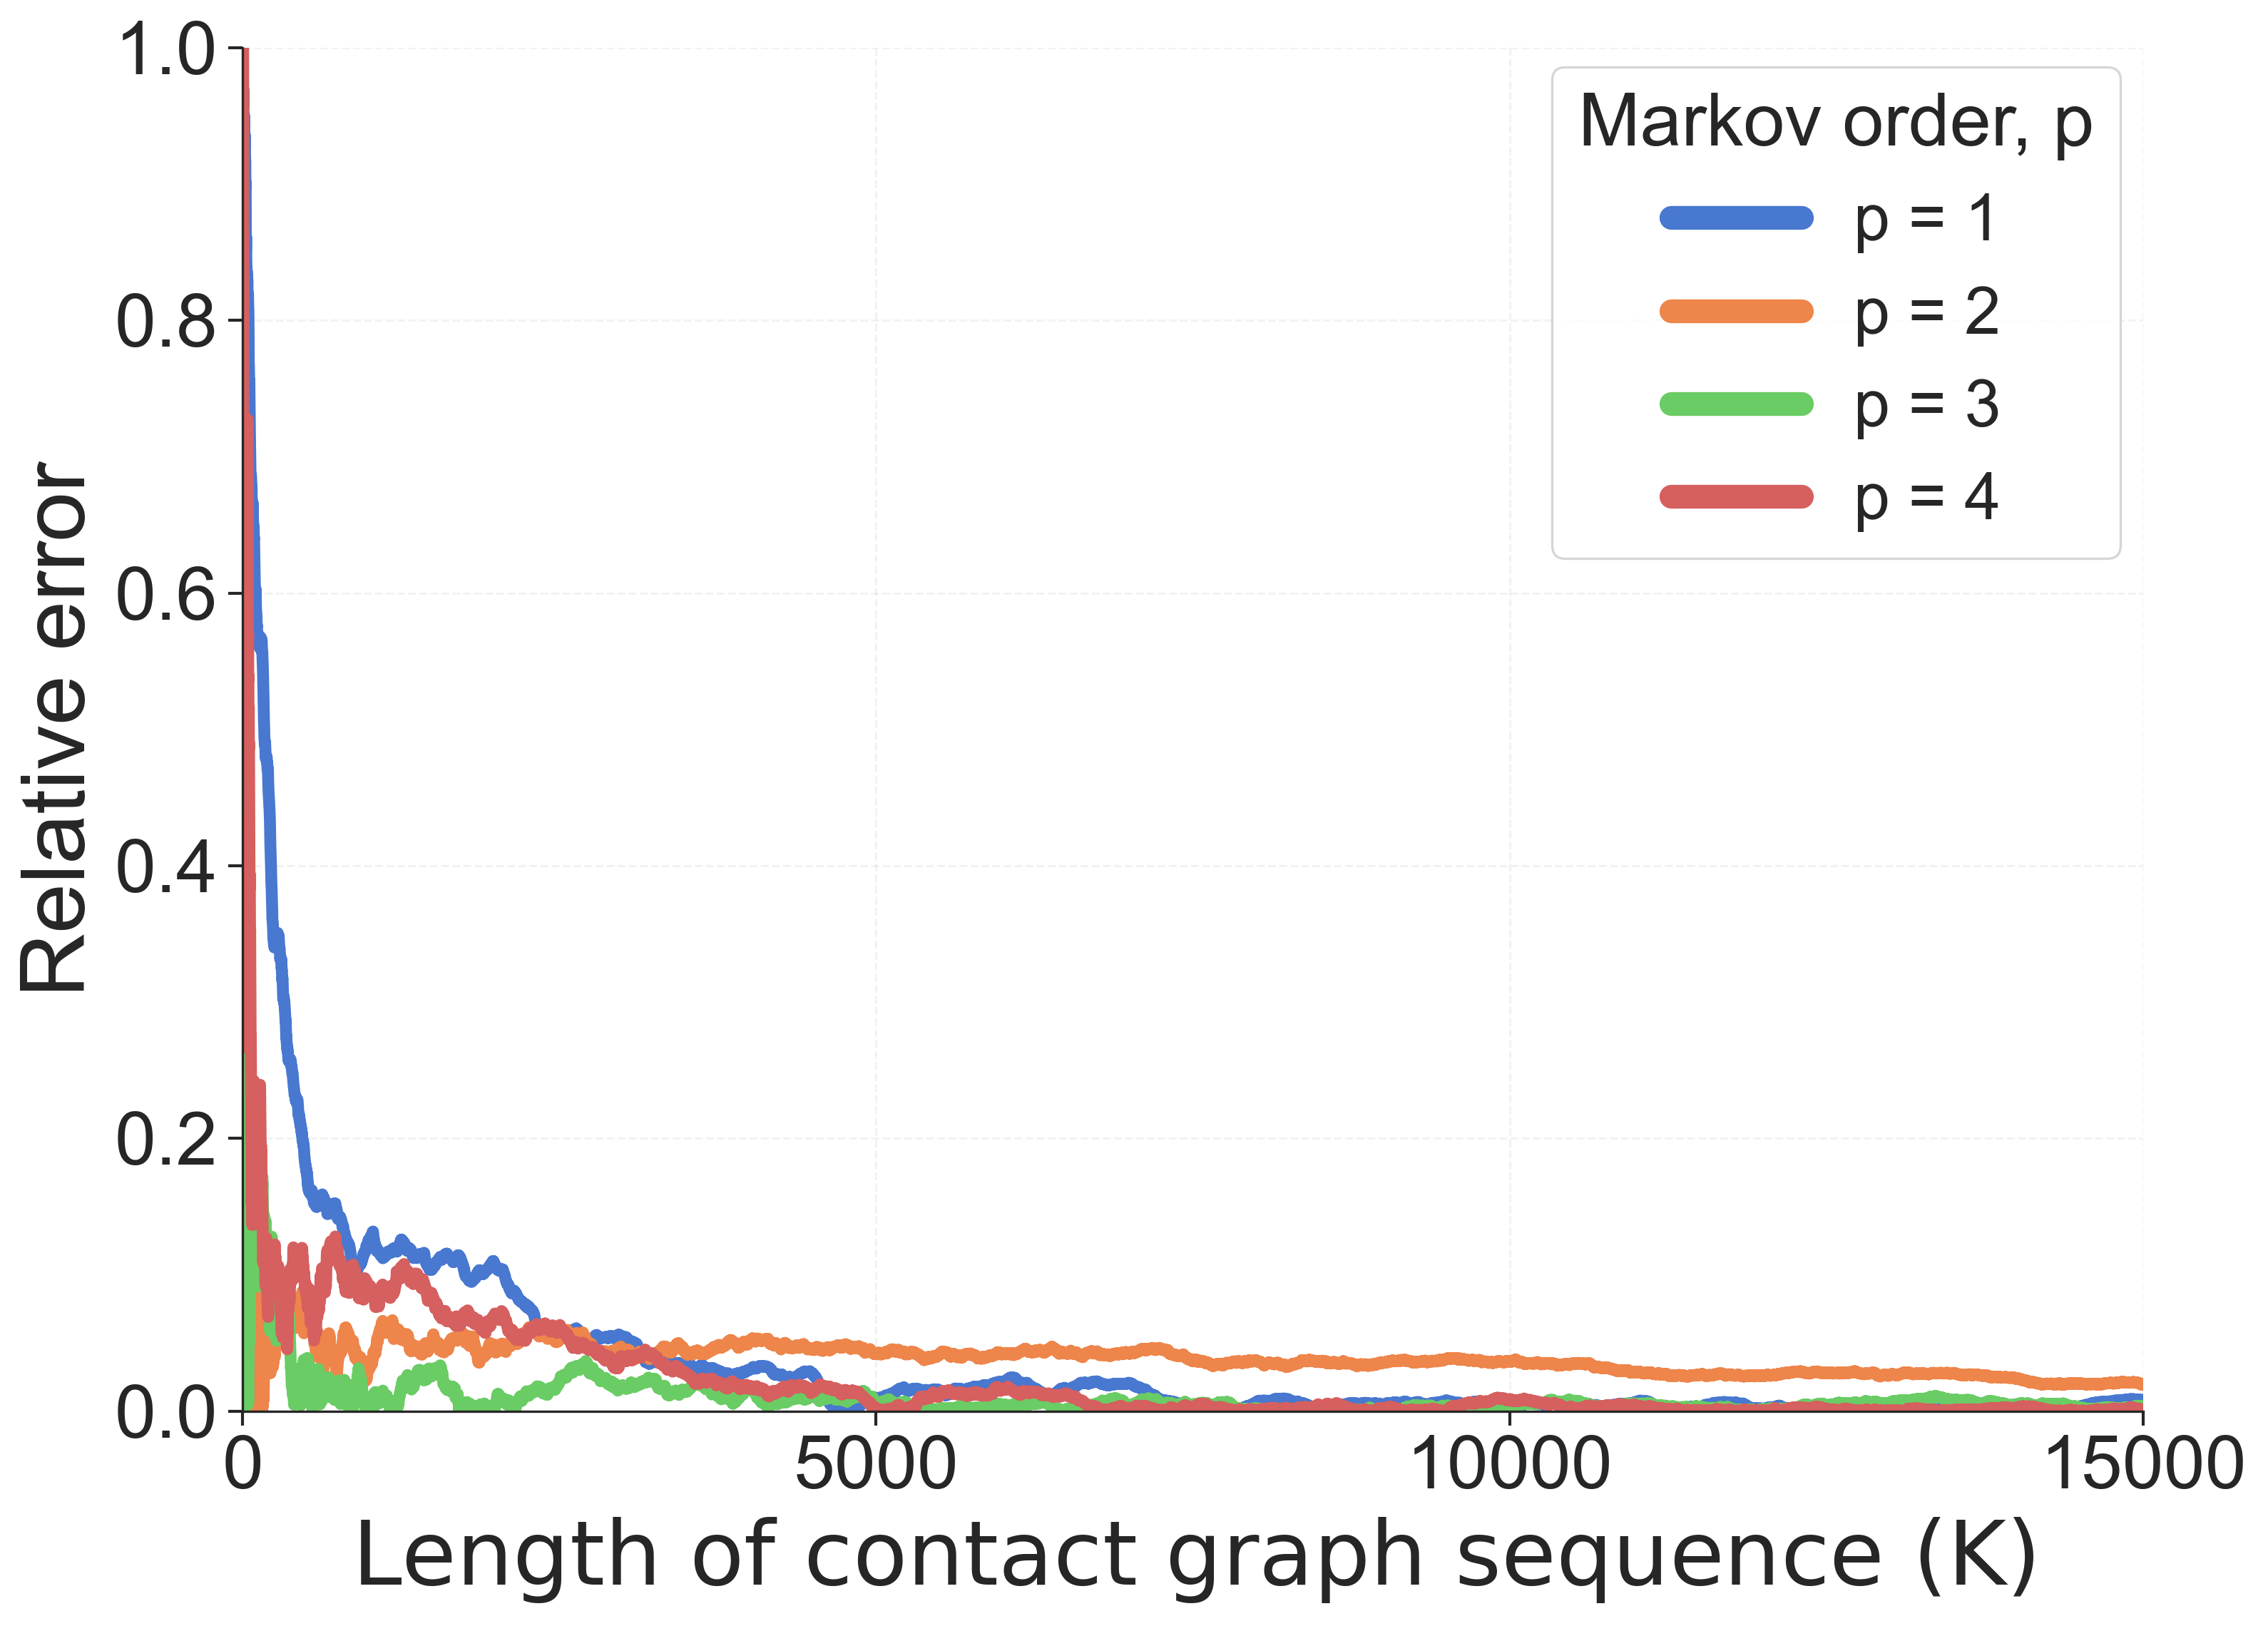

In [5]:
plot_order_convergence(
    rel_error,
    global_max=15000,
    filename="convergence_3_order_single_time.png",
    tick_size = 5000
)

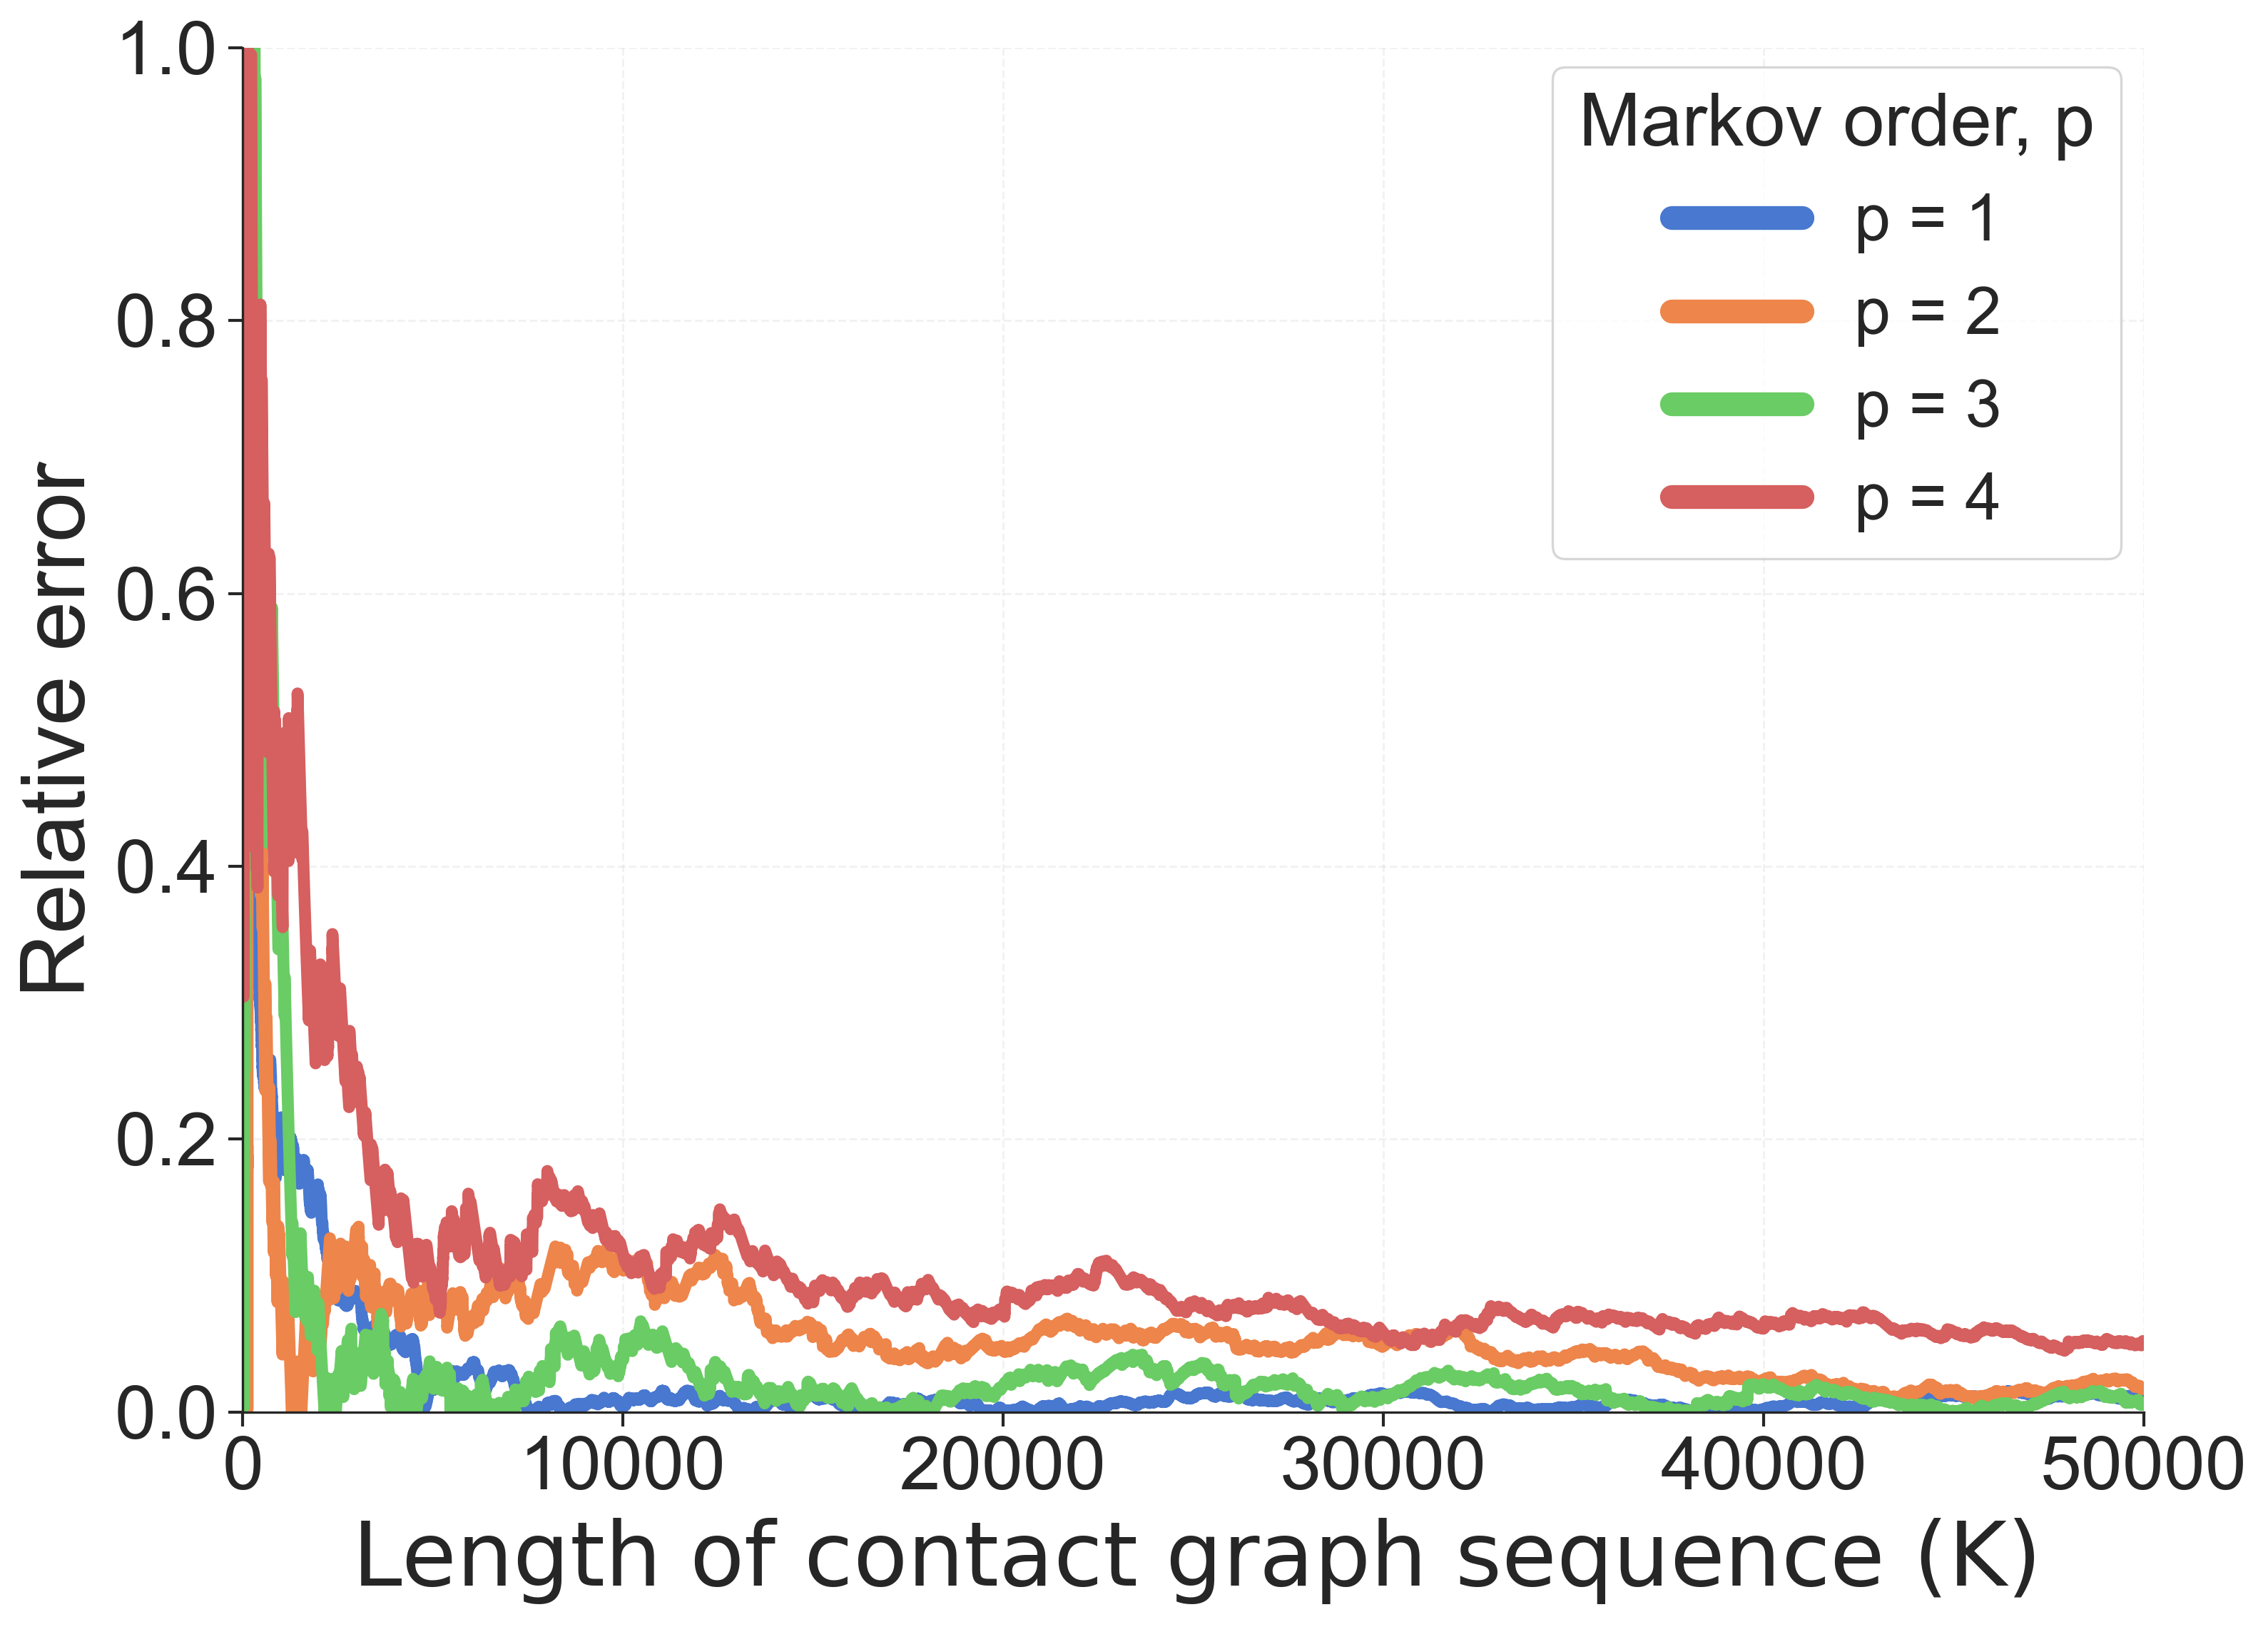

In [6]:
plot_order_convergence(
    rel_error2,
    global_max=50000, 
    filename="convergence_3_order_consecutive_times.png",
    tick_size = 10000
)